In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [48]:
nav = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

txn = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [49]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [50]:
print(txn.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [51]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [52]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

In [53]:
nav["daily_return"] = (

    nav.groupby("amfi_code")["nav"]

       .pct_change()

)

In [54]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [55]:
var_results = []

In [56]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    var_results.append(
        [code,var95]
    )

In [57]:
var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [58]:
cvar_results = []

In [59]:
for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    cvar_results.append(
        [code,cvar95]
    )

In [60]:
cvar_df = pd.DataFrame(
    cvar_results,
    columns=[
        "amfi_code",
        "CVaR_95"
    ]
)

cvar_df.head()

,amfi_code,CVaR_95
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [61]:
risk_report = var_df.merge(
    cvar_df,
    on="amfi_code"
)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [62]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [63]:
print(perf.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [64]:
# Rolling 90 days sharpe ratio.

key_funds = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

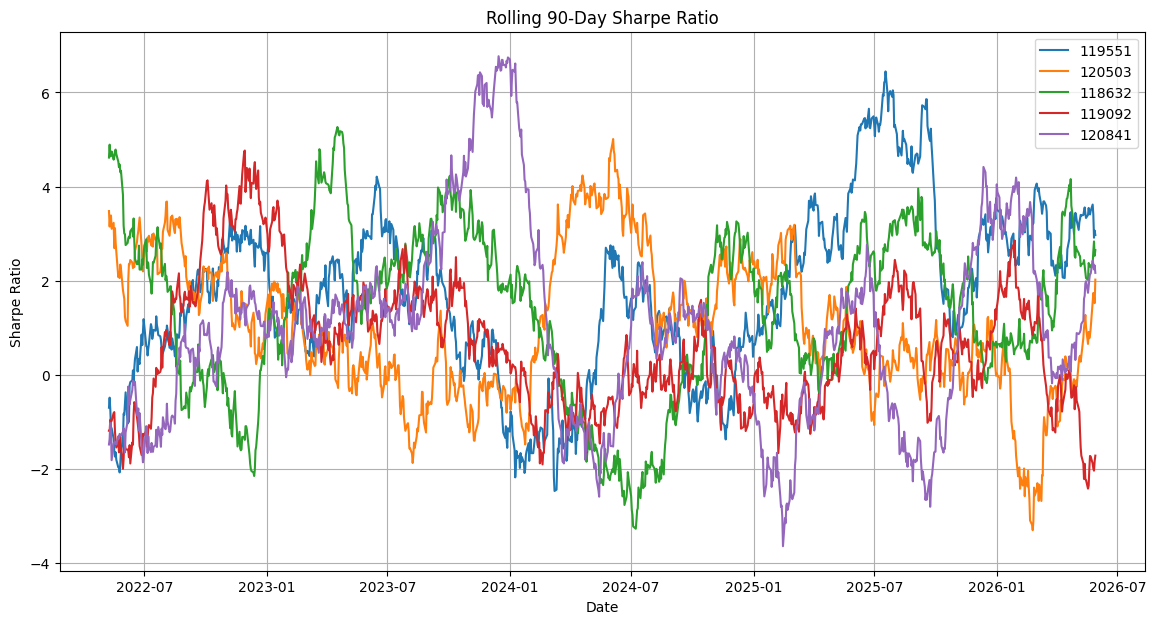

In [65]:
plt.figure(figsize=(14,7))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (

        temp["daily_return"]
        .rolling(90)
        .mean()

        /

        temp["daily_return"]
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

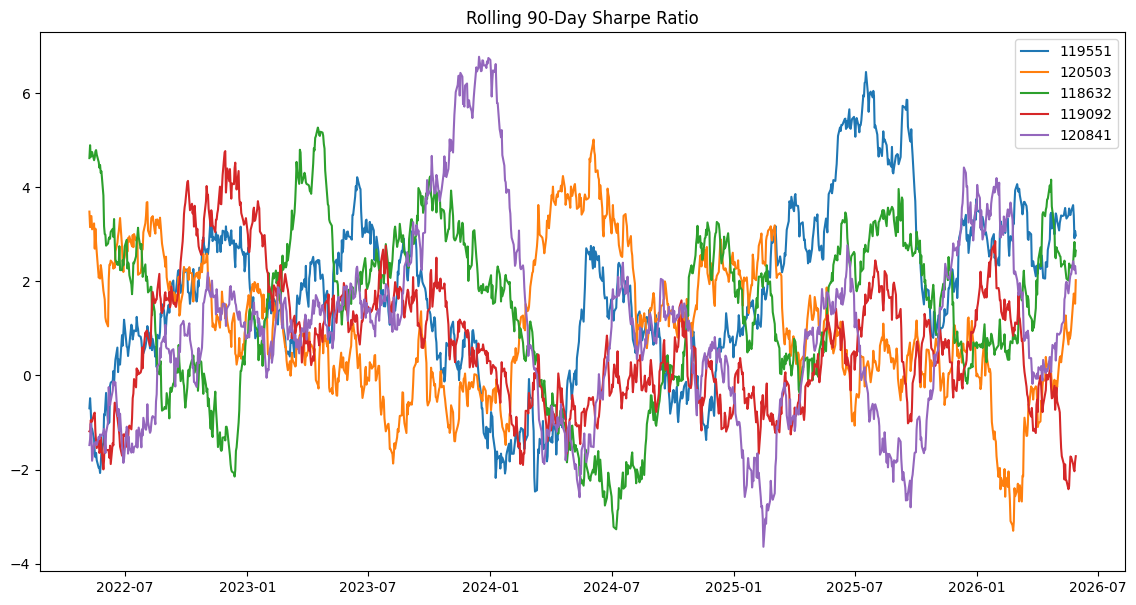

In [66]:
plt.figure(figsize=(14,7))

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (

        temp["daily_return"]
        .rolling(90)
        .mean()

        /

        temp["daily_return"]
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

In [67]:
# Investor Coherent Analysis

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

In [68]:
first_txn = (

    txn.groupby("investor_id")

       ["transaction_date"]

       .min()

       .reset_index()

)

In [69]:
first_txn["cohort_year"] = (

    first_txn["transaction_date"]

    .dt.year

)

In [70]:
txn = txn.merge(

    first_txn[
        ["investor_id",
         "cohort_year"]
    ],

    on="investor_id"

)

In [71]:
cohort = (

    txn.groupby("cohort_year")

    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )

    .reset_index()

)

cohort

,cohort_year,avg_sip_amount,total_invested
0,2024,107992.41476,712641945


In [72]:
cohort

,cohort_year,avg_sip_amount,total_invested
0,2024,107992.41476,712641945


In [73]:
# Top Fund Preference per Cohort

top_funds = (

    txn.groupby(
        ["cohort_year",
         "amfi_code"]
    )

    .size()

    .reset_index(
        name="count"
    )

)

In [74]:
top_funds = (

    top_funds

    .sort_values(
        ["cohort_year","count"],
        ascending=False
    )

    .groupby("cohort_year")

    .head(1)

)

In [75]:
top_funds

,cohort_year,amfi_code,count
33,2024,125498,204


In [76]:
cohort.head()


,cohort_year,avg_sip_amount,total_invested
0,2024,107992.41476,712641945


In [77]:
top_funds.head()

,cohort_year,amfi_code,count
33,2024,125498,204


In [78]:
txn["transaction_date"].dt.year.value_counts().sort_index()

transaction_date
2024    6599
Name: count, dtype: int64

In [79]:
# SIP Continuity Analysis

sip = txn[
    txn["transaction_type"] == "SIP"
].copy()

In [80]:
sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [81]:
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

In [82]:
sip["gap_days"] = (

    sip.groupby("investor_id")

    ["transaction_date"]

    .diff()

    .dt.days

)

In [83]:
sip.head(10)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
93,INV000006,2024-01-02,118633,SIP,8594,Madhya Pradesh,Bhopal,B30,46-55,Female,43.0,Cheque,Verified,2024,NaN
2376,INV000006,2024-02-07,102885,SIP,8440,Madhya Pradesh,Bhopal,B30,46-55,Female,43.0,Cheque,Verified,2024,36.0
163,INV000007,2024-01-03,119094,SIP,13603,Uttar Pradesh,Kanpur,B30,26-35,Male,21.9,Mandate,Verified,2024,NaN
3245,INV000009,2024-02-20,119093,SIP,28650,Haryana,Gurugram,T30,26-35,Male,17.1,Cheque,Verified,2024,NaN
6467,INV000010,2024-04-11,120506,SIP,2855,Maharashtra,Pune,T30,36-45,Male,13.6,Mandate,Verified,2024,NaN
166,INV000011,2024-01-03,120507,SIP,2230,West Bengal,Kolkata,T30,26-35,Male,9.6,Mandate,Verified,2024,NaN
1334,INV000011,2024-01-22,101207,SIP,2641,West Bengal,Kolkata,T30,26-35,Male,9.6,UPI,Verified,2024,19.0


In [84]:
# Avg gap per investor
continuity = (

    sip.groupby("investor_id")

    .agg({

        "gap_days":"mean",

        "transaction_date":"count"

    })

)

In [85]:
continuity.columns = [

    "avg_gap_days",

    "sip_count"

]

In [86]:
continuity = continuity[
    continuity["sip_count"] >= 6
]

In [87]:
continuity["status"] = np.where(

    continuity["avg_gap_days"] > 35,

    "At Risk",

    "Healthy"

)

In [88]:
continuity["status"].value_counts()

status
Healthy    1
Name: count, dtype: int64

In [89]:
# Sector HHI Concentration

holdings["weight"] = (

    holdings["weight_pct"]

    / 100

)

In [90]:
# caluclate HHI
hhi = (

    holdings

    .groupby("amfi_code")

    ["weight"]

    .apply(

        lambda x:

        (x**2).sum()

    )

    .reset_index()

)

In [91]:
hhi.columns = [

    "amfi_code",

    "HHI"

]

In [92]:
hhi.sort_values(

    "HHI",

    ascending=False

).head()

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298


# Insights from the Advance Analytics.

## Insight -1
Fund Hdfc Mutual fund (100025) recorded the highest
95% VaR indicating the largest downside risk.

## Insight - 2

The 2024 investor cohort contributed ₹71.26 crore in investments, with an average transaction size of ₹1.08 lakh.

# Insight - 3
[HDFC Mid-Cap Opportunities Fund - Direct - Growth] emerged as the most preferred fund among new investors, recording 204 transactions from the 2024 cohort.

# Insight - 4
Fund SBI  achieved the strongest
rolling Sharpe ratio during 2025.

# Insight - 5
[Fund Name] displayed the highest portfolio concentration with an HHI of 0.2064, suggesting lower diversification relative to competing equity funds.